In [33]:
import os
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
import torch
import torch.optim as optim
import glob

from PIL import Image
import nibabel as nib
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import random
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders

# Data
TRAINING_DATA_PATH = "../data/raw/training/"
PREPROC_DATA_PATH = "../data/preprocessed/"
TEMP_PREPROC_DATA_PATH = "../data/preprocessed/temp"
VOLUMES_PREPROC_DATA_PATH = "../data/preprocessed/volumes"
MASKS_PREPROC_DATA_PATH = "../data/preprocessed/masks"
SPLIT_PREPROC_DATA_PATH = "../data/preprocessed/split/"

Path(TEMP_PREPROC_DATA_PATH).mkdir(parents=True, exist_ok=True)
Path(PREPROC_DATA_PATH).mkdir(parents=True, exist_ok=True)
Path(VOLUMES_PREPROC_DATA_PATH).mkdir(parents=True, exist_ok=True)
Path(MASKS_PREPROC_DATA_PATH).mkdir(parents=True, exist_ok=True)
Path(SPLIT_PREPROC_DATA_PATH).mkdir(parents=True, exist_ok=True)

T1CE_SUFFIX = "_t1ce.nii"
T2_SUFFIX = "_t2.nii"
FLAIR_SUFFIX = "_flair.nii"
SEG_SUFFIX = "_seg.nii"

RAND_SEED = 18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("NVIDIA Cuda available: ", torch.cuda.is_available())
print("GPU: ", torch.cuda.get_device_name(0))

NVIDIA Cuda available:  True
GPU:  NVIDIA GeForce GTX 1050 Ti


### Single image preprocessing

In [12]:
test_img = nib.load(TRAINING_DATA_PATH + "BraTS20_Training_355/BraTS20_Training_355" + FLAIR_SUFFIX).get_fdata()
test_seg = nib.load(TRAINING_DATA_PATH + "BraTS20_Training_355/BraTS20_Training_355" + SEG_SUFFIX).get_fdata().astype(np.uint8)
print(test_img.shape, test_img.max())
print(test_seg.shape, np.unique(test_seg), f"label 3 count: {len(test_seg[test_seg==3.])}")

(240, 240, 155) 1854.603271484375
(240, 240, 155) [0 1 2 4] label 3 count: 0


In [13]:
scaler = MinMaxScaler()
scaled_test_img = scaler.fit_transform(test_img.reshape(-1, test_img.shape[-1])).reshape(test_img.shape)
print(scaled_test_img.shape, scaled_test_img.max())

(240, 240, 155) 1.0


In [14]:
scaler = MinMaxScaler()

def scale_volume(vol, scaler):
    return scaler.fit_transform(vol.reshape(-1, vol.shape[-1])).reshape(vol.shape)

In [15]:
test_flair = nib.load(TRAINING_DATA_PATH + "BraTS20_Training_096/BraTS20_Training_096" + FLAIR_SUFFIX).get_fdata()
test_t1ce = nib.load(TRAINING_DATA_PATH + "BraTS20_Training_096/BraTS20_Training_096" + T1CE_SUFFIX).get_fdata()
test_t2 = nib.load(TRAINING_DATA_PATH + "BraTS20_Training_096/BraTS20_Training_096" + T2_SUFFIX).get_fdata()

test_seg = nib.load(TRAINING_DATA_PATH + "BraTS20_Training_096/BraTS20_Training_096" + SEG_SUFFIX).get_fdata()

# Scale & Cast
test_flair = scale_volume(test_flair, scaler)
test_t1ce = scale_volume(test_t1ce, scaler)
test_t2 = scale_volume(test_t2, scaler)
print("Sequences scaled to [0, 1]")

test_seg = test_seg.astype(np.uint8)
test_seg[test_seg == 4] = 3
print(f"Segmentation casted to uint8  & remapped label 3 to 4 - Labels: {np.unique(test_seg)}")

Sequences scaled to [0, 1]
Segmentation casted to uint8  & remapped label 3 to 4 - Labels: [0 1 2 3]


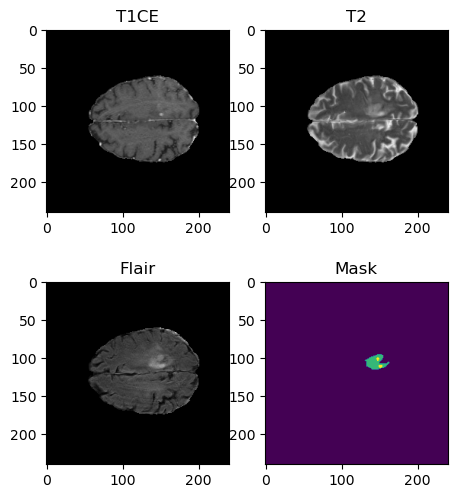

In [16]:
n_slice = random.randint(0, test_seg.shape[-1])

plt.figure(figsize=(8, 6))

plt.subplot(231)
plt.imshow(test_t1ce[:,:,n_slice], cmap="gray")
plt.title("T1CE")

plt.subplot(232)
plt.imshow(test_t2[:,:,n_slice], cmap="gray")
plt.title("T2")

plt.subplot(234)
plt.imshow(test_flair[:,:,n_slice], cmap="gray")
plt.title("Flair")

plt.subplot(235)
plt.imshow(test_seg[:,:,n_slice])
plt.title("Mask")

plt.show()

In [22]:
stacked = np.stack([test_t1ce, test_t2, test_flair], axis=3)
stacked = stacked[56:184, 56:184, 13:141]
test_seg = test_seg[56:184, 56:184, 13:141]
np.save(PREPROC_DATA_PATH + "temp/stacked_355.npy", stacked)
stacked = np.load(PREPROC_DATA_PATH + "temp/stacked_355.npy")
stacked.shape

(128, 128, 128, 3)

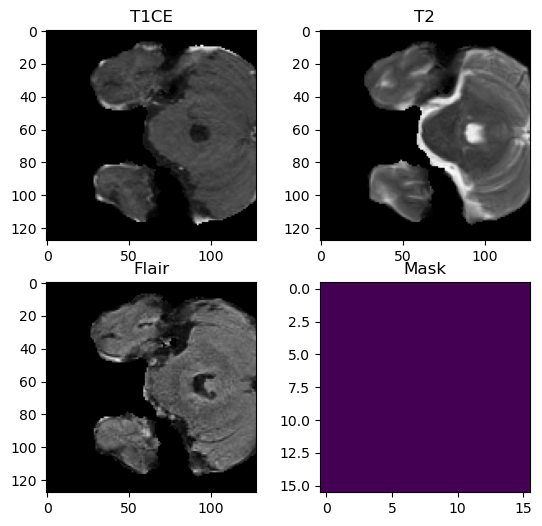

In [23]:
n_slice = random.randint(0, test_seg.shape[-1])

plt.figure(figsize=(10, 6))

plt.subplot(231)
plt.imshow(stacked[:,:,n_slice, 0], cmap="gray")
plt.title("T1CE")

plt.subplot(232)
plt.imshow(stacked[:,:,n_slice, 1], cmap="gray")
plt.title("T2")

plt.subplot(234)
plt.imshow(stacked[:,:,n_slice, 2], cmap="gray")
plt.title("Flair")

plt.subplot(235)
plt.imshow(test_seg[:,:,n_slice])
plt.title("Mask")

plt.show()

In [24]:
val, counts = np.unique(test_seg, return_counts=True)
print(f"Amount of ceros in mask (in [0, 1]): {1 - (counts[0]/counts.sum()):.2f}")

mask_torch = torch.from_numpy(test_seg).long() # one hot needs long
mask_one_hot = F.one_hot(mask_torch, num_classes=4).to(torch.uint8)
# Can be converted back to numpy with mask_one_hot.numpy()

print(f"OneHot for labels - Old shape: {test_seg.shape}, New shape: {mask_one_hot.shape}")

Amount of ceros in mask (in [0, 1]): 0.00
OneHot for labels - Old shape: (16, 16, 102), New shape: torch.Size([16, 16, 102, 4])


### All data preprocessing

In [25]:
t1ce_files = sorted(glob.glob(TRAINING_DATA_PATH + "*/*" + T1CE_SUFFIX))
t2_files = sorted(glob.glob(TRAINING_DATA_PATH + "*/*" + T2_SUFFIX))
flair_files = sorted(glob.glob(TRAINING_DATA_PATH + "*/*" + FLAIR_SUFFIX))
seg_files = sorted(glob.glob(TRAINING_DATA_PATH + "*/*" + SEG_SUFFIX))

print(f"Found {len(t1ce_files)} - {len(t2_files)} - {len(flair_files)} - {len(seg_files)} files")

Found 369 - 369 - 369 - 369 files


In [ ]:
scaler = MinMaxScaler()

for i in tqdm(range(len(seg_files)), "Preprocessing data"):
    t1ce_img = nib.load(t1ce_files[i]).get_fdata()
    t2_img = nib.load(t2_files[i]).get_fdata()
    flair_img = nib.load(flair_files[i]).get_fdata()
    seg_img = nib.load(seg_files[i]).get_fdata()

    # Scale & Cast
    t1ce_img = scale_volume(t1ce_img, scaler)
    t2_img = scale_volume(t2_img, scaler)
    flair_img = scale_volume(flair_img, scaler)

    seg_img = seg_img.astype(np.uint8)
    seg_img[seg_img == 4] = 3

    stacked = np.stack([t1ce_img, t2_img, flair_img], axis=3)
    stacked = stacked[56:184, 56:184, 13:141]
    seg_img = seg_img[56:184, 56:184, 13:141]

    val, counts = np.unique(seg_img, return_counts=True)

    if (1 - (counts[0]/counts.sum())) > 0.01: # Ignore if mostly empty
        mask_torch = torch.from_numpy(seg_img).long()
        mask_one_hot = F.one_hot(mask_torch, num_classes=4).to(torch.uint8)
        np.save(PREPROC_DATA_PATH + f"volumes/volume_{str(i)}.npy", stacked)
        np.save(PREPROC_DATA_PATH + f"masks/seg_{str(i)}.npy", mask_one_hot.numpy())

Preprocessing data:  46%|█████████████████████████████████████▎                                           | 170/369 [02:22<02:25,  1.37it/s]

In [10]:
# Train-Test
splitfolders.ratio(PREPROC_DATA_PATH, output=SPLIT_PREPROC_DATA_PATH, seed=RAND_SEED, ratio=(0.8, 0.2))

Copying files: 688 files [00:32, 21.39 files/s]


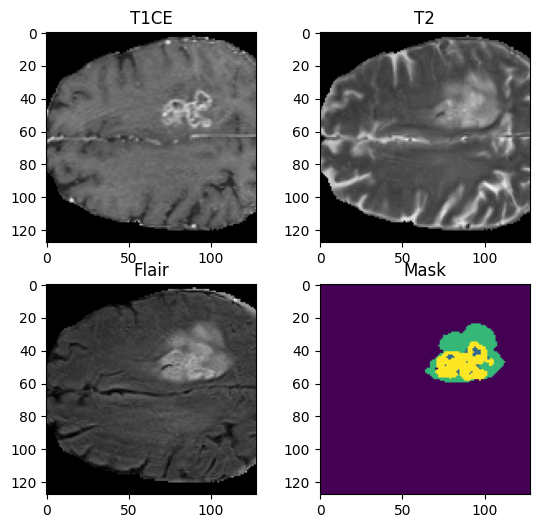

In [25]:
stacked = np.load(SPLIT_PREPROC_DATA_PATH + "train/volumes/volume_95.npy")
mask = np.load(SPLIT_PREPROC_DATA_PATH + "train/masks/seg_95.npy")
mask = torch.argmax(torch.from_numpy(mask), dim=-1).numpy()

n_slice = random.randint(0, mask.shape[-1])

plt.figure(figsize=(10, 6))

plt.subplot(231)
plt.imshow(stacked[:,:,n_slice, 0], cmap="gray")
plt.title("T1CE")

plt.subplot(232)
plt.imshow(stacked[:,:,n_slice, 1], cmap="gray")
plt.title("T2")

plt.subplot(234)
plt.imshow(stacked[:,:,n_slice, 2], cmap="gray")
plt.title("Flair")

plt.subplot(235)
plt.imshow(mask[:,:,n_slice])
plt.title("Mask")

plt.show()

In [2]:
from typing import cast
import torch.utils.checkpoint as cp

class UNet3DCheckpoint(nn.Module):
    def __init__(self, in_channels=3, num_classes=4, base_ch=16):
        super().__init__()

        # Encoder
        self.enc0 = self._conv_block(in_channels, base_ch)
        self.enc1 = self._conv_block(base_ch, base_ch*2)
        self.enc2 = self._conv_block(base_ch*2, base_ch*4)
        self.enc3 = self._conv_block(base_ch*4, base_ch*8)
        self.enc4 = self._conv_block(base_ch*8, base_ch*16)

        # Decoder
        self.up1 = self._up_block(base_ch*16, base_ch*8)
        self.up2 = self._up_block(base_ch*8*2, base_ch*4)
        self.up3 = self._up_block(base_ch*4*2, base_ch*2)
        self.up4 = self._up_block(base_ch*2*2, base_ch)

        self.final = nn.Conv3d(base_ch*2, num_classes, kernel_size=1)

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose3d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm3d(out_ch),
        )

    def forward(self, x):
        e0 = cast(torch.Tensor, cp.checkpoint(
            self.enc0, x, use_reentrant=False))
        e1 = cast(torch.Tensor, cp.checkpoint(
            lambda t: self.enc1(nn.functional.max_pool3d(t, 2)), e0, use_reentrant=False))
        e2 = cast(torch.Tensor, cp.checkpoint(
            lambda t: self.enc2(nn.functional.max_pool3d(t, 2)), e1, use_reentrant=False))
        e3 = cast(torch.Tensor, cp.checkpoint(
            lambda t: self.enc3(nn.functional.max_pool3d(t, 2)), e2, use_reentrant=False))
        e4 = cast(torch.Tensor, cp.checkpoint(
            lambda t: self.enc4(nn.functional.max_pool3d(t, 2)), e3, use_reentrant=False))

        d1 = self.up1(e4)
        d1 = torch.cat([d1, e3], dim=1)
        d2 = self.up2(d1)
        d2 = torch.cat([d2, e2], dim=1)
        d3 = self.up3(d2)
        d3 = torch.cat([d3, e1], dim=1)
        d4 = self.up4(d3)
        d4 = torch.cat([d4, e0], dim=1)

        out = self.final(d4)
        return torch.sigmoid(out)

model = UNet3DCheckpoint().to(device)
model.load_state_dict(torch.load("../unet3d_brats_amp.pth", weights_only=True))

<All keys matched successfully>

69


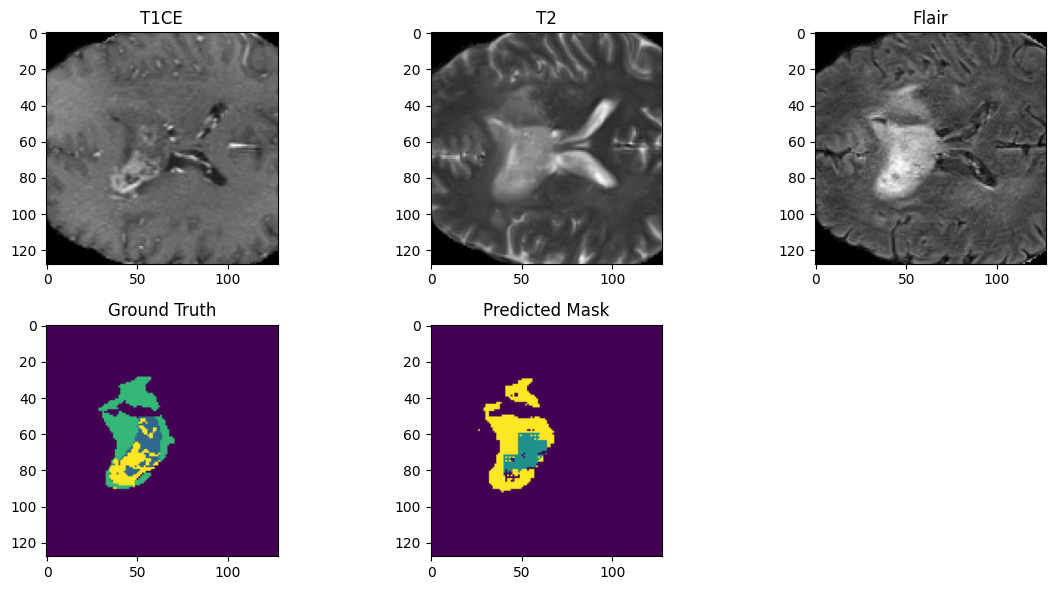

In [14]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

stacked = np.load(SPLIT_PREPROC_DATA_PATH + "train/volumes/volume_94.npy")
mask = np.load(SPLIT_PREPROC_DATA_PATH + "train/masks/seg_94.npy")
mask_onehot = torch.from_numpy(mask).float()
mask_class = torch.argmax(mask_onehot, dim=-1).numpy()

n_slice = random.randint(0, mask.shape[2])
print(n_slice)

img = torch.tensor(stacked).unsqueeze(0).float().permute(0, 4, 3, 1, 2).to(device)

model.eval()
with torch.no_grad():
    output = model(img)
    output_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

pred_slice = output_mask[n_slice, :, :]
gt_slice = mask_class[:, :, n_slice]

# Plot
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(stacked[:, :, n_slice, 0], cmap="gray")
plt.title("T1CE")

plt.subplot(2, 3, 2)
plt.imshow(stacked[:, :, n_slice, 1], cmap="gray")
plt.title("T2")

plt.subplot(2, 3, 3)
plt.imshow(stacked[:, :, n_slice, 2], cmap="gray")
plt.title("Flair")

plt.subplot(2, 3, 4)
plt.imshow(gt_slice)
plt.title("Ground Truth")

plt.subplot(2, 3, 5)
plt.imshow(pred_slice)
plt.title("Predicted Mask")

plt.tight_layout()
plt.show()